In [18]:
import numpy as np
import pandas as pd
import os
# import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import direction_utils as utils
import direction_learning_utils as train_utils

torch.manual_seed(0)
torch.cuda.manual_seed(0) 
np.random.seed(0)

In [2]:
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=32):
        super(SEBlock, self).__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)  # Output size: (batch_size, in_channels, 1, 1)
        
        # self.fc1 = nn.Linear(in_channels, max(1, in_channels // reduction), bias=False)  # Squeeze
        self.fc1 = nn.Linear(in_channels, in_channels // reduction, bias=False)  # Squeeze

        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(in_channels // reduction, in_channels, bias=False)  # Excitation
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        batch_size, channels, height, width = x.size()
        
        # Squeeze: Global Average Pooling
        out = self.global_avg_pool(x).view(batch_size, channels)  # Shape: (batch_size, in_channels)
        
        # Excitation: Fully connected layers
        out = self.fc1(out)  # Shape: (batch_size, in_channels // reduction)
        out = self.relu(out)
        out = self.fc2(out)  # Shape: (batch_size, in_channels)
        out = self.sigmoid(out).view(batch_size, channels, 1, 1)  # Reshape to (batch_size, in_channels, 1, 1)
        
        # Scale the input by the SE weights
        return x * out.expand_as(x)

In [3]:
class SEBlockPerChannel(nn.Module):
    def __init__(self, height, width, reduction=16):
        super(SEBlockPerChannel, self).__init__()
        self.height = height
        self.width = width
        
        # Fully connected layers to learn the importance of each height (electrode) for each channel
        self.fc1 = nn.Linear(height, height // reduction, bias=False)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(height // reduction, height, bias=False)
        self.sigmoid = nn.Sigmoid()

        self.channel_weights = None

    def forward(self, x):
        # Input x shape: (batch_size, channels, height, width)
        b, c, h, w = x.size()
        
        # Initialize a list to store the reweighted channels
        output = []
        # print(f'Shape of X Before SE: {x.size()}')

        # Loop over each channel (for each filter)
        electrode_scale = []
        for i in range(c):
            # Extract the i-th channel (filter): shape (batch_size, height, width)
            y = x[:, i, :, :]
            # print(f'Shape of X for filter {i} SE: {y.size()}')

            # Squeeze: Average pooling along the width (temporal dimension)
            y_squeezed = y.mean(dim=-1)  # shape: (batch_size, height)
            # print(f"Shape before FC1 (y_squeezed): {y_squeezed.shape}")
            # print(f'Shape of X for filter {i} Pooling Layer SE: {y_squeezed.size()}')
            
            # Excitation: Fully connected layers to assign weights to the height dimension
            y_fc1 = self.fc1(y_squeezed)
            # print(f'Shape of X for filter {i} FC Layer1 SE: {y_fc1.size()}')
            y_relu = self.relu(y_fc1)

            y_fc2 = self.fc2(y_relu)
            # print(f'Shape of X for filter {i} FC Layer2 SE: {y_fc2.size()}')

            y_sigmoid = self.sigmoid(y_fc2)  # shape: (batch_size, height)

            electrode_scale.append(y_sigmoid.mean(dim=0, keepdim=True).detach().cpu())
            
            # Reshape to (batch_size, 1, height, 1) to broadcast
            y_sigmoid = y_sigmoid.view(b, 1, h, 1)
            # print(f'Shape of X for filter {i} Sigmoid SE: {y_sigmoid.size()}')
            
            # Scale the original channel data
            y_scaled = y.unsqueeze(1) * y_sigmoid.expand_as(y.unsqueeze(1))  # Reshape y to (batch_size, 1, height, width)
            # print(f'Shape of X for filter {i} After SE: {y_scaled.size()}')
            
            # Append to output list
            output.append(y_scaled)
        
        # Concatenate along the channel dimension to restore the original shape
        output = torch.cat(output, dim=1)  # shape: (batch_size, channels, height, width)
        # print(f'Shape of X for After SE: {output.size()}')
        self.channel_weights = torch.cat(electrode_scale, dim=0)
        
        return output


In [4]:
class EEGNet(nn.Module):
    def __init__(self, nb_classes, Chans=27, Samples=2500, dropoutRate=0.5, 
                 kernLength=64, F1=8, D=2, F2=16, norm_rate=0.25, dropoutType='Dropout'):
        super(EEGNet, self).__init__()
        
        # Handle dropout type
        if dropoutType == 'SpatialDropout2D':
            self.dropout = nn.Dropout2d(dropoutRate)
        elif dropoutType == 'Dropout':
            self.dropout = nn.Dropout(dropoutRate)
        else:
            raise ValueError('dropoutType must be one of SpatialDropout2D or Dropout.')

        # Block 1
        self.conv1 = nn.Conv2d(1, F1, (1, kernLength), padding='same', bias=False)
        self.batchnorm1 = nn.BatchNorm2d(F1)
        # Squeeze-and-Excitation Block
        self.se_electrode1 = SEBlockPerChannel(Chans, Samples, reduction=3)
        self.se_electrode2 = SEBlockPerChannel(Chans, Samples, reduction=3)
        self.se1 = SEBlock(F1, 3)


        self.depthwiseConv = nn.Conv2d(F1, F1*D, (Chans, 1), groups=F1, bias=False)
        self.batchnorm2 = nn.BatchNorm2d(F1*D)
        self.se2 = SEBlock(F1*D, 3)  # Squeeze-and-Excitation Block
        self.pool1 = nn.AvgPool2d((1, 4))

        # Block 2
        self.separableConv = nn.Conv2d(F1*D, F2, (1, 16), padding='same', bias=False)
        self.batchnorm3 = nn.BatchNorm2d(F2)
        self.se3 = SEBlock(F2, 3)  # Squeeze-and-Excitation Block
        self.pool2 = nn.AvgPool2d((1, 8))

        # Flatten and Dense
        self.flatten = nn.Flatten()
        self.dense = nn.Linear(F2 * (Samples // (4 * 8)), nb_classes)
        self.norm_constraint = nn.utils.weight_norm(self.dense)
        
        #For Debuggin and Analysis
        self.electrode_weights_layer1 = None
        self.electrode_weights_layer2 = None
        
    def forward(self, x):
        # Block 1
        x = self.se_electrode1(x)
        self.electrode_weights_layer1 = self.se_electrode1.channel_weights
        x = self.conv1(x)
        x = self.batchnorm1(x)
        x = self.se_electrode2(x)
        self.electrode_weights_layer2 = self.se_electrode2.channel_weights
        x = self.se1(x)
        x = self.depthwiseConv(x)
        x = self.batchnorm2(x)
        x = F.elu(x)
        x = self.se2(x)
        x = self.pool1(x)
        x = self.dropout(x)

        # Block 2
        x = self.separableConv(x)
        x = self.batchnorm3(x)
        x = F.elu(x)
        x = self.se3(x)
        x = self.pool2(x)
        x = self.dropout(x)

        # Flatten and Dense
        x = self.flatten(x)
        x = self.dense(x)
        return F.softmax(x, dim=1)

In [5]:
def model_using_calibration_data(verbose=False):
    torch.manual_seed(0)
    parent_dir = os.path.dirname(os.getcwd())
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    batch_size=32
    fs = 500
    train_ratio = 0.9
    sub = 7 #Till subject 7 (starting from 0), only calibration sessions are conducted

    # Xtr, Ytr = create_dataset(sub, base_path=parent_dir)
    Xtr, Ytr = utils.calib_sess_dataset(base_path=parent_dir)
    # Creating train-validation split

    eeg_train, eeg_val, label_train, label_val = train_test_split(Xtr, Ytr, 
                                                                train_size=train_ratio, random_state=42, shuffle=True)
    
    train_loader = train_utils.convert_to_tensor(eeg_train, label_train)
    val_loader = train_utils.convert_to_tensor(eeg_val, label_val)

    

    # X_train = utils.baseline_correction(Xtr)
    # X_train = utils.bandpass_filtering(X_train)

    # X_train_tensor = torch.tensor(eeg_train, dtype=torch.float32).unsqueeze(1).permute(0, 1, 3, 2).to(device)  # Shape: (batch_size, 1, 27, 2500)
    # Y_train_tensor = torch.tensor(label_train, dtype=torch.long).to(device)  # Use long for classification

    # X_val_tensor = torch.tensor(eeg_val, dtype=torch.float32).unsqueeze(1).permute(0, 1, 3, 2).to(device)  # Shape: (batch_size, 1, 27, 2500)
    # Y_val_tensor = torch.tensor(label_val, dtype=torch.long).to(device)

    # train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
    # test_dataset = TensorDataset(X_val_tensor, Y_val_tensor)

    # train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    # val_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)


    model = EEGNet(nb_classes=2, Chans=27, Samples=2000).to(device)
    # optimizer = optim.Adam(model.parameters(), lr=1e-3)
    trained_model = train_utils.model_training(model, train_loader, val_loader, verbose=verbose)
    # torch.save(trained_model.state_dict(), 'calibrated_EEGNetSEPerElectrode_model.pth')  # Save best model
    torch.save(trained_model.state_dict(), 'basedEEGNetSE_model.pth')

    return trained_model
    

In [6]:
def evaluation_on_online_data(model_file):
    torch.manual_seed(0)
    parent_dir = os.path.dirname(os.getcwd())
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    batch_size=32

    model = EEGNet(nb_classes=2, Chans=27, Samples=2000).to(device)
    model.load_state_dict(torch.load(f'{model_file}.pth'))

    # hook_handle = model.se_electrode1.sigmoid.register_forward_hook(forward_hook)


    online_perf = dict()
    el_ranks_at_layer1 = []
    el_ranks_at_layer2 = []
    for sub in range(8, 21):
        Xtr, Ytr, Xte, Yte = utils.online_sess_dataset(sub, base_path=parent_dir)
        batch_size = Yte.size
        # print(batch_size)
        test_loader = train_utils.convert_to_tensor(Xte, Yte, batch_size=batch_size)

        test_loss, test_acc, layer1_el_rank, layer2_el_rank = train_utils.model_evaluation(model, test_loader)
        # Append layer1_el_rank to el_ranks_at_layer1
        # Append layer2_el_rank to el_ranks_at_layer2

        el_ranks_at_layer1.append(layer1_el_rank)
        el_ranks_at_layer2.append(layer2_el_rank)

        online_perf[f'Sub{sub:02d}'] = test_acc
        
        print(f'Subject: {sub:02d}, Test Accuracy: {test_acc:.2f}%')

    print(f'Average Accuracy: {np.mean(list(online_perf.values()))}')
    print(list(online_perf.values()))

    return el_ranks_at_layer1, el_ranks_at_layer2
    

In [ ]:
# Model Training on Calibration and Testing on Online Session Data
trained_model = model_using_calibration_data(verbose=True)
# evaluation_on_online_data('calibrated_eegnetSE_model')

In [8]:
# evaluation_on_online_data('calibrated_EEGNetSEPerElectrode_model')
el_rank1, el_rank2 = evaluation_on_online_data('basedEEGNetSE_model')


d:\Praveen\PostDoc@SIT\.venv\Lib\site-packages\torch\nn\utils\weight_norm.py:134: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
C:\Users\postd\AppData\Local\Temp\ipykernel_6492\3068921490.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `

Subject: 08, Test Accuracy: 54.17%
Subject: 09, Test Accuracy: 54.17%
Subject: 10, Test Accuracy: 50.00%
Subject: 11, Test Accuracy: 41.67%
Subject: 12, Test Accuracy: 60.42%
Subject: 13, Test Accuracy: 64.58%
Subject: 14, Test Accuracy: 66.67%
Subject: 15, Test Accuracy: 54.17%
Subject: 16, Test Accuracy: 50.00%
Subject: 17, Test Accuracy: 70.83%
Subject: 18, Test Accuracy: 64.58%
Subject: 19, Test Accuracy: 56.25%
Subject: 20, Test Accuracy: 64.58%
Average Accuracy: 57.8525641025641
[54.166666666666664, 54.166666666666664, 50.0, 41.66666666666667, 60.416666666666664, 64.58333333333334, 66.66666666666666, 54.166666666666664, 50.0, 70.83333333333334, 64.58333333333334, 56.25, 64.58333333333334]


In [34]:
# Convert the list to a NumPy array (13x27)
el_ranks_array = np.array(el_rank1)
electrodes = ['Fp1', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F3', 
              'F1', 'Fz', 'F2', 'F4', 'FC3', 'FC1', 'FCz', 'FC2', 
              'FC4', 'C3', 'C1', 'Cz', 'C2', 'C4', 'CP3', 'CP1', 
              'CPz', 'CP2', 'CP4']

# Create a heatmap using Seaborn
plt.figure(figsize=(8, 4))  # Adjust the figure size if needed
sns.heatmap(el_ranks_array, cmap='coolwarm', annot=False, fmt=".2f", cbar=True, 
            xticklabels=[i for i in electrodes], 
            yticklabels=[f"Sub{i+8:02d}" for i in range(13)])  # For subjects 8 to 20

# Add labels and title
plt.title('Electrode Ranks at Layer 1')
plt.xlabel('Electrode')
plt.ylabel('Subject')

# Show the plot
plt.tight_layout()  # Adjust layout to fit labels
# plt.show()

# Save the figure as an SVG file (you can adjust the filename as needed)
plt.savefig(f'subject_electrode_ranks.svg', format='svg')

# Optionally, show the plot
plt.close()  # Close the plot to free up memory and avoid overlap with the next subject



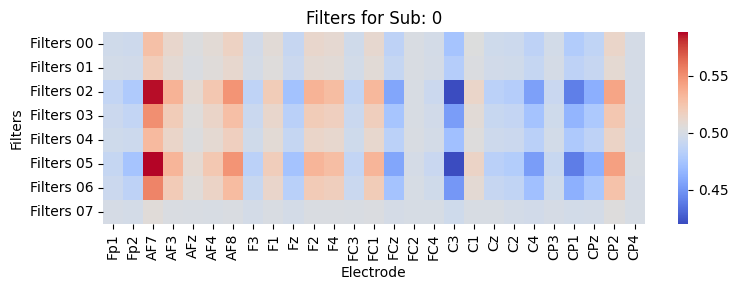

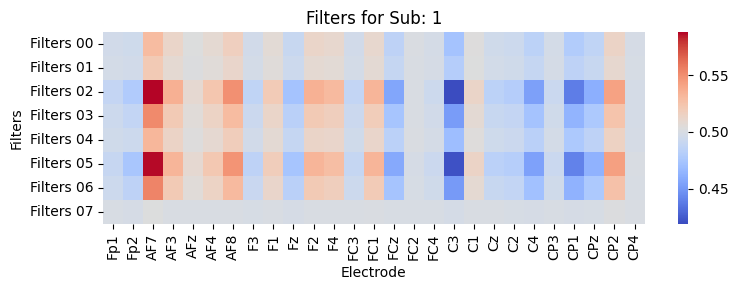

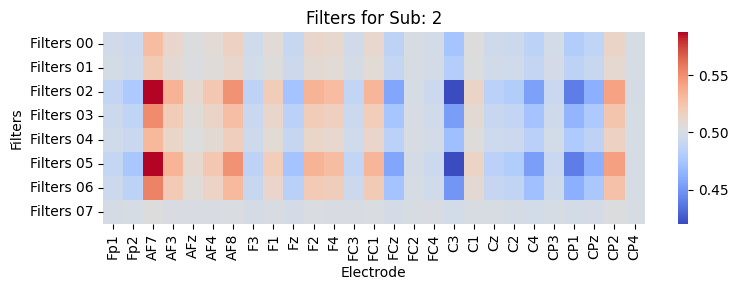

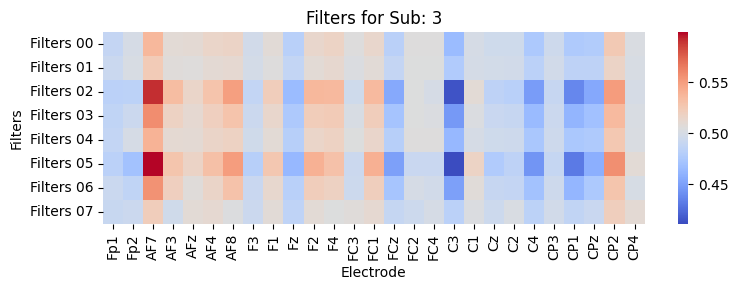

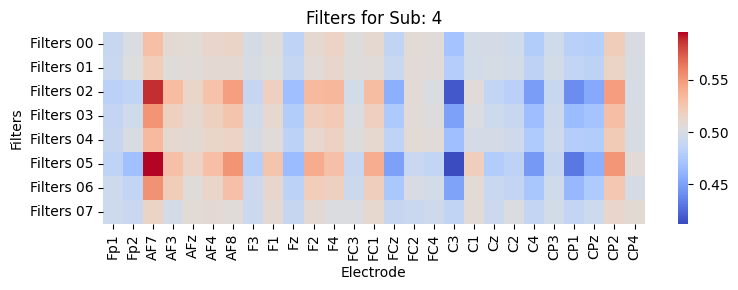

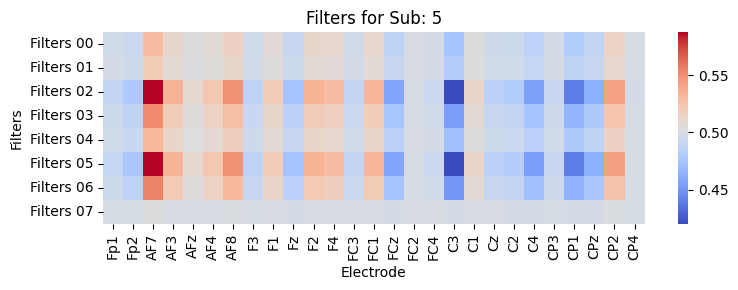

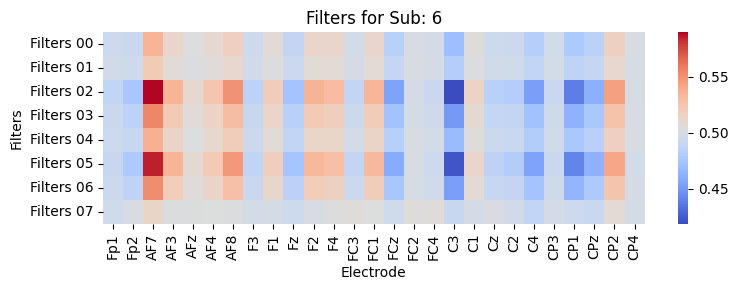

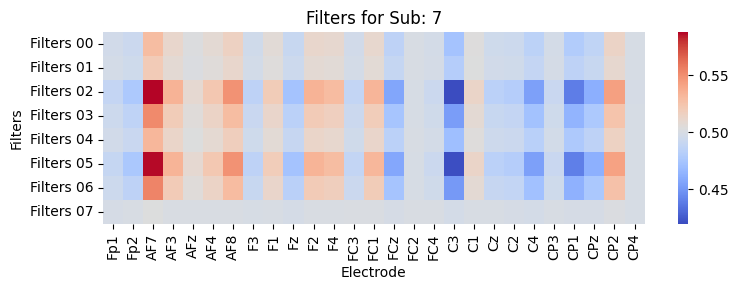

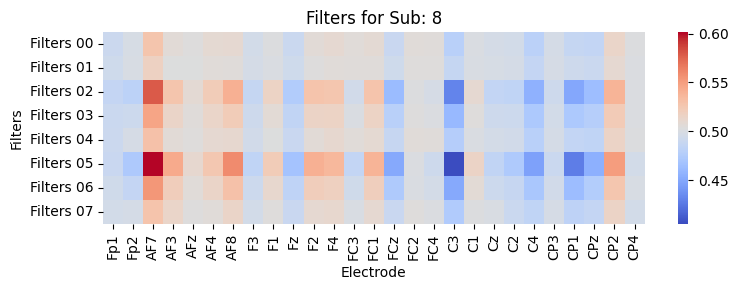

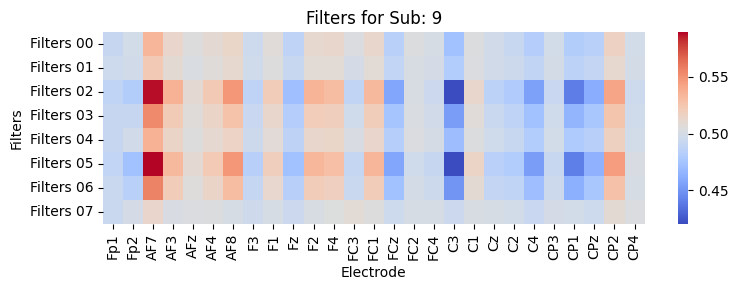

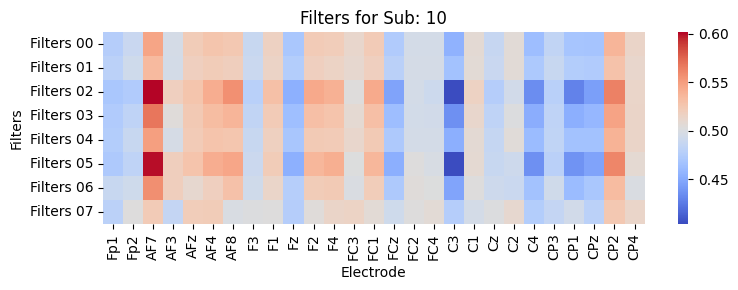

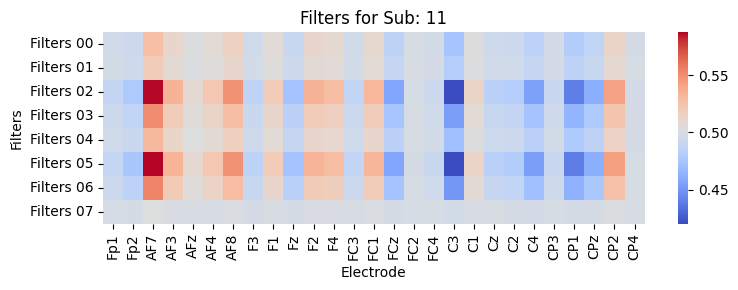

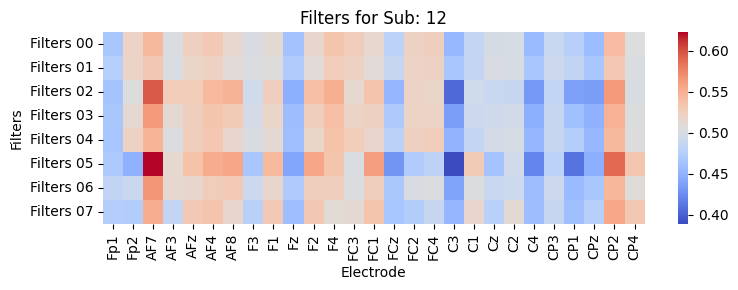

In [32]:
# Assuming `el_ranks_at_layer2` has the shape (13, 8, 27), corresponding to 13 subjects, 
# 8 filters, and 27 electrodes.

# Example shape: (13, 8, 27) = [Subjects, Filters, Electrodes]

# feat_ranks = np.array(el_rank2)
# Iterate through each subject (13 subjects)
for sub_idx in range(13):
    # Get the electrode ranks for the current subject (shape: [8, 27] for the 8 filters and 27 electrodes)
    feat_ranks = np.array(el_rank2[sub_idx])
    
    # Create a figure to plot all 8 heatmaps for the filters of the current subject
    # Create a heatmap using Seaborn
    plt.figure(figsize=(8, 3))  # Adjust the figure size if needed
    sns.heatmap(feat_ranks, cmap='coolwarm', annot=False, fmt=".2f", cbar=True, 
                xticklabels=[i for i in electrodes], 
                yticklabels=[f"Filters {i:02d}" for i in range(8)])  # For Filters 1 to 8

    # Add labels and title
    plt.title(f'Filters for Sub: {sub_idx}' )
    plt.xlabel('Electrode')
    plt.ylabel('Filters')

    # Show the plot
    plt.tight_layout()  # Adjust layout to fit labels
    plt.show()
    
    



In [9]:
# Model Fine Tuning
def model_fine_tuning_params(model_file, seLayer = False, denseLayer=True, conv2dLayer=False):

    torch.manual_seed(0)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = EEGNet(nb_classes=2, Chans=27, Samples=2000).to(device)
    model.load_state_dict(torch.load(f'{model_file}.pth'))

    # for param in model.parameters():
    #         param.requires_grad = False

    # # Unfreeze the last layer parameters
    # for param in model.se_electrode1.parameters():
    #     param.requires_grad = True  # Unfreeze last layer
    
    # # Unfreeze the last layer parameters
    # for param in model.se1.parameters():
    #     param.requires_grad = True  # Unfreeze last layer
    
    # # Unfreeze the last layer parameters
    # for param in model.se2.parameters():
    #     param.requires_grad = True  # Unfreeze last layer
    
    # # Unfreeze the last layer parameters
    # for param in model.se3.parameters():
    #     param.requires_grad = True  # Unfreeze last layer


    if denseLayer or conv2dLayer or seLayer:

        if seLayer:
            print(f'SE layer is fine-tuned')
            
            for param in model.parameters():
                param.requires_grad = False

            # Unfreeze the last layer parameters
            for param in model.se_electrode1.parameters():
                param.requires_grad = True  # Unfreeze last layer
            
            # Unfreeze the last layer parameters
            for param in model.se_electrode2.parameters():
                param.requires_grad = True  # Unfreeze last layer

            # # Unfreeze the last layer parameters
            # for param in model.se1.parameters():
            #     param.requires_grad = True  # Unfreeze last layer
        
            # # Unfreeze the last layer parameters
            # for param in model.se2.parameters():
            #     param.requires_grad = True  # Unfreeze last layer
            
            # # Unfreeze the last layer parameters
            # for param in model.se3.parameters():
            #     param.requires_grad = True  # Unfreeze last layer

        if denseLayer:
            print(f'Dense layer is fine-tuned')
            # Freeze all layers except the last one
            for param in model.dense.parameters():
                param.requires_grad = True  # Freeze all parameters

        if conv2dLayer:
            print(f'Conv2D layer is fine-tuned')
            # Unfreeze the last layer parameters
            for param in model.separableConv.parameters():
                param.requires_grad = True  # Unfreeze last layer

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

    return model, optimizer


In [ ]:
def subject_specific_fine_tuning(seLayer = False, denseLayer=True, conv2dLayer=False):
    parent_dir = os.path.dirname(os.getcwd())
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    Xcalib, Ycalib = utils.calib_sess_dataset(base_path=parent_dir)

    train_ratio = 0.9
    batch_size=32
    online_perf = dict()

    model_file = 'calibrated_EEGNetSEPerElectrode_model'
    for sub in range(8, 21):
        Xtr, Ytr, Xte, Yte = utils.online_sess_dataset(sub, base_path=parent_dir)
        eeg_train, eeg_val, label_train, label_val = train_test_split(Xtr, Ytr, 
                                                                train_size=train_ratio, random_state=42, shuffle=True)
        
        # Xtrain = np.concatenate((Xcalib, eeg_train), axis=0)
        # Ytrain = np.concatenate((Ycalib, label_train), axis=0)
        Xtrain = eeg_train
        Ytrain = label_train
        
        train_loader = train_utils.convert_to_tensor(Xtrain, Ytrain)
        val_loader = train_utils.convert_to_tensor(eeg_val, label_val)

        model, optimizer = model_fine_tuning_params(model_file, seLayer = seLayer, denseLayer=denseLayer, conv2dLayer=conv2dLayer)
        torch.save(model.state_dict(), 'latest_best_model.pth')  # Save best model
        model_file = 'latest_best_model'

        trained_model = train_utils.model_training(model, train_loader, val_loader, Tuning=True)

        test_loader = train_utils.convert_to_tensor(Xte, Yte)

        # model = EEGNet(nb_classes=2, Chans=27, Samples=2000).to(device)
        # model.load_state_dict(torch.load('trained_model_checkpoint.pth'))

        test_loss, test_acc = train_utils.model_evaluation(trained_model, test_loader)

        print(f'Subject: {sub:02d}, Test Accuracy: {test_acc:.2f}%')
        online_perf[f'Sub{sub:02d}'] = test_acc

    print(f'Average Accuracy: {np.mean(list(online_perf.values()))}')
    print(list(online_perf.values()))


In [ ]:
subject_specific_fine_tuning(seLayer=True, denseLayer=False, conv2dLayer=False, mdl_name='ElRank')

C:\Users\postd\AppData\Local\Temp\ipykernel_7532\3244971408.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'{model_file}.pth'))


SE layer is fine-tuned
Subject: 08, Test Accuracy: 50.00%
SE layer is fine-tuned
Subject: 09, Test Accuracy: 56.25%
SE layer is fine-tuned
Subject: 10, Test Accuracy: 42.19%
SE layer is fine-tuned
Subject: 11, Test Accuracy: 54.69%
SE layer is fine-tuned
Subject: 12, Test Accuracy: 51.56%
SE layer is fine-tuned
Subject: 13, Test Accuracy: 65.62%
SE layer is fine-tuned
Subject: 14, Test Accuracy: 64.06%
SE layer is fine-tuned
Subject: 15, Test Accuracy: 51.56%
SE layer is fine-tuned
Subject: 16, Test Accuracy: 51.56%
SE layer is fine-tuned
Subject: 17, Test Accuracy: 67.19%
SE layer is fine-tuned
Subject: 18, Test Accuracy: 57.81%
SE layer is fine-tuned
Subject: 19, Test Accuracy: 64.06%
SE layer is fine-tuned
Subject: 20, Test Accuracy: 71.88%
Average Accuracy: 57.57211538461539
[50.0, 56.25, 42.1875, 54.6875, 51.5625, 65.625, 64.0625, 51.5625, 51.5625, 67.1875, 57.8125, 64.0625, 71.875]


In [12]:
subject_specific_fine_tuning(seLayer=False, denseLayer=True, conv2dLayer=False)

C:\Users\postd\AppData\Local\Temp\ipykernel_7532\3244971408.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'{model_file}.pth'))


Dense layer is fine-tuned
Subject: 08, Test Accuracy: 54.69%
Dense layer is fine-tuned
Subject: 09, Test Accuracy: 51.56%
Dense layer is fine-tuned
Subject: 10, Test Accuracy: 45.31%
Dense layer is fine-tuned
Subject: 11, Test Accuracy: 54.69%
Dense layer is fine-tuned
Subject: 12, Test Accuracy: 51.56%
Dense layer is fine-tuned
Subject: 13, Test Accuracy: 65.62%
Dense layer is fine-tuned
Subject: 14, Test Accuracy: 64.06%
Dense layer is fine-tuned
Subject: 15, Test Accuracy: 56.25%
Dense layer is fine-tuned
Subject: 16, Test Accuracy: 51.56%
Dense layer is fine-tuned
Subject: 17, Test Accuracy: 64.06%
Dense layer is fine-tuned
Subject: 18, Test Accuracy: 65.62%
Dense layer is fine-tuned
Subject: 19, Test Accuracy: 70.31%
Dense layer is fine-tuned
Subject: 20, Test Accuracy: 70.31%
Average Accuracy: 58.89423076923077
[54.6875, 51.5625, 45.3125, 54.6875, 51.5625, 65.625, 64.0625, 56.25, 51.5625, 64.0625, 65.625, 70.3125, 70.3125]


In [13]:
subject_specific_fine_tuning(seLayer=True, denseLayer=True, conv2dLayer=False)

C:\Users\postd\AppData\Local\Temp\ipykernel_7532\3244971408.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'{model_file}.pth'))


SE layer is fine-tuned
Dense layer is fine-tuned
Subject: 08, Test Accuracy: 50.00%
SE layer is fine-tuned
Dense layer is fine-tuned
Subject: 09, Test Accuracy: 53.12%
SE layer is fine-tuned
Dense layer is fine-tuned
Subject: 10, Test Accuracy: 43.75%
SE layer is fine-tuned
Dense layer is fine-tuned
Subject: 11, Test Accuracy: 57.81%
SE layer is fine-tuned
Dense layer is fine-tuned
Subject: 12, Test Accuracy: 51.56%
SE layer is fine-tuned
Dense layer is fine-tuned
Subject: 13, Test Accuracy: 67.19%
SE layer is fine-tuned
Dense layer is fine-tuned
Subject: 14, Test Accuracy: 65.62%
SE layer is fine-tuned
Dense layer is fine-tuned
Subject: 15, Test Accuracy: 54.69%
SE layer is fine-tuned
Dense layer is fine-tuned
Subject: 16, Test Accuracy: 48.44%
SE layer is fine-tuned
Dense layer is fine-tuned
Subject: 17, Test Accuracy: 67.19%
SE layer is fine-tuned
Dense layer is fine-tuned
Subject: 18, Test Accuracy: 56.25%
SE layer is fine-tuned
Dense layer is fine-tuned
Subject: 19, Test Accuracy:

In [14]:
subject_specific_fine_tuning(seLayer=True, denseLayer=True, conv2dLayer=True)

C:\Users\postd\AppData\Local\Temp\ipykernel_7532\3244971408.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'{model_file}.pth'))


SE layer is fine-tuned
Dense layer is fine-tuned
Conv2D layer is fine-tuned
Subject: 08, Test Accuracy: 53.12%
SE layer is fine-tuned
Dense layer is fine-tuned
Conv2D layer is fine-tuned
Subject: 09, Test Accuracy: 60.94%
SE layer is fine-tuned
Dense layer is fine-tuned
Conv2D layer is fine-tuned
Subject: 10, Test Accuracy: 43.75%
SE layer is fine-tuned
Dense layer is fine-tuned
Conv2D layer is fine-tuned
Subject: 11, Test Accuracy: 54.69%
SE layer is fine-tuned
Dense layer is fine-tuned
Conv2D layer is fine-tuned
Subject: 12, Test Accuracy: 51.56%
SE layer is fine-tuned
Dense layer is fine-tuned
Conv2D layer is fine-tuned
Subject: 13, Test Accuracy: 67.19%
SE layer is fine-tuned
Dense layer is fine-tuned
Conv2D layer is fine-tuned
Subject: 14, Test Accuracy: 65.62%
SE layer is fine-tuned
Dense layer is fine-tuned
Conv2D layer is fine-tuned
Subject: 15, Test Accuracy: 48.44%
SE layer is fine-tuned
Dense layer is fine-tuned
Conv2D layer is fine-tuned
Subject: 16, Test Accuracy: 48.44%
S

In [15]:
subject_specific_fine_tuning(seLayer=False, denseLayer=False, conv2dLayer=False)

C:\Users\postd\AppData\Local\Temp\ipykernel_7532\3244971408.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'{model_file}.pth'))


Subject: 08, Test Accuracy: 54.69%
Subject: 09, Test Accuracy: 51.56%
Subject: 10, Test Accuracy: 45.31%
Subject: 11, Test Accuracy: 54.69%
Subject: 12, Test Accuracy: 51.56%
Subject: 13, Test Accuracy: 65.62%
Subject: 14, Test Accuracy: 64.06%
Subject: 15, Test Accuracy: 56.25%
Subject: 16, Test Accuracy: 51.56%
Subject: 17, Test Accuracy: 64.06%
Subject: 18, Test Accuracy: 65.62%
Subject: 19, Test Accuracy: 70.31%
Subject: 20, Test Accuracy: 70.31%
Average Accuracy: 58.89423076923077
[54.6875, 51.5625, 45.3125, 54.6875, 51.5625, 65.625, 64.0625, 56.25, 51.5625, 64.0625, 65.625, 70.3125, 70.3125]


In [32]:
print(np.mean([56.25, 56.25, 56.25, 59.375, 51.5625, 59.375, 62.5, 57.8125, 51.5625, 73.4375]))


58.4375


In [ ]:
# Analysis of the ranks assigned to each electrodes.
